<a href="https://colab.research.google.com/github/sgsinghashka-del/Logistic-Regression_30-Practical-Projects/blob/main/logistic_regression_30_Practical_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Pass / Fail Prediction (Study Hours)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
# a
# Load dataset
data = pd.read_csv("studyhrs.csv")

# Features and target
X = data[["Study Hours"]]
y = data["Result"]

# Convert Pass/Fail into 1/0
y = y.map({"Fail": 0, "Pass": 1})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Logistic Regression model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Predict for new student
hours = float(input("Enter study hours: "))

prediction = model.predict([[hours]])
probability = model.predict_proba([[hours]])[0][1]

if prediction[0] == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

print("Probability of passing:", round(probability * 100, 2), "%")

Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4

Enter study hours: 10
Prediction: PASS
Probability of passing: 99.99 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


2. Employee Attrition (Years in Company)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



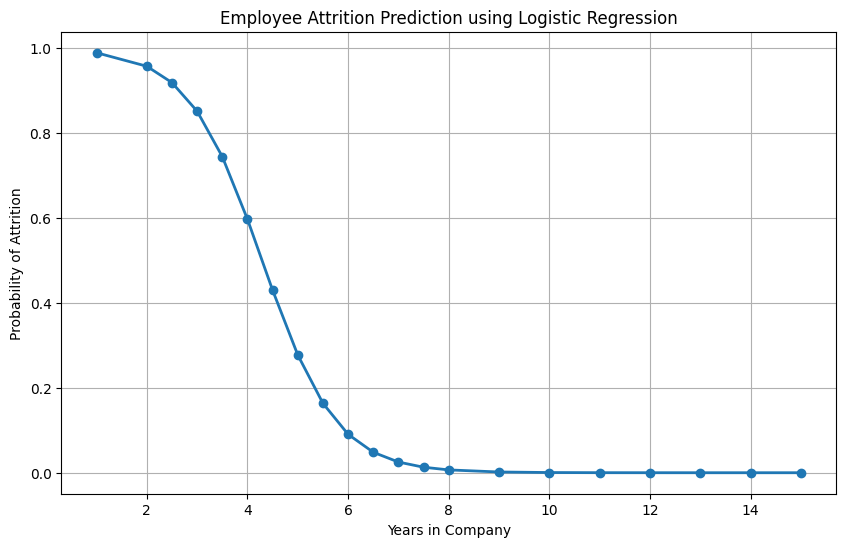


 Enter years in company: 11
Prediction: Employee may STAY
Probability of Attrition: 0.01 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# a
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = pd.read_csv("employee_attrition.csv")

# Input and output
X = data[["Years in Company"]]
y = data["Attrition"].map({"No": 0, "Yes": 1})

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Test prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --------------------------------
# LINE GRAPH
# --------------------------------

# Sort data for a smooth line
graph_data = data.sort_values("Years in Company")

X_graph = graph_data[["Years in Company"]]

# Probability of employee leaving
probability = model.predict_proba(X_graph)[:, 1]

plt.figure(figsize=(10, 6))

plt.plot(
    X_graph["Years in Company"],
    probability,
    marker="o",
    linewidth=2
)

plt.xlabel("Years in Company")
plt.ylabel("Probability of Attrition")
plt.title("Employee Attrition Prediction using Logistic Regression")

plt.grid(True)
plt.show()

# --------------------------------
# NEW EMPLOYEE PREDICTION
# --------------------------------

years = float(input("\n Enter years in company: "))

prediction = model.predict([[years]])
probability_new = model.predict_proba([[years]])[0][1]

if prediction[0] == 1:
    print("Prediction: Employee may LEAVE")
else:
    print("Prediction: Employee may STAY")

print(
    "Probability of Attrition:",
    round(probability_new * 100, 2),
    "%"
)

3. Email Spam Detection

Accuracy: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



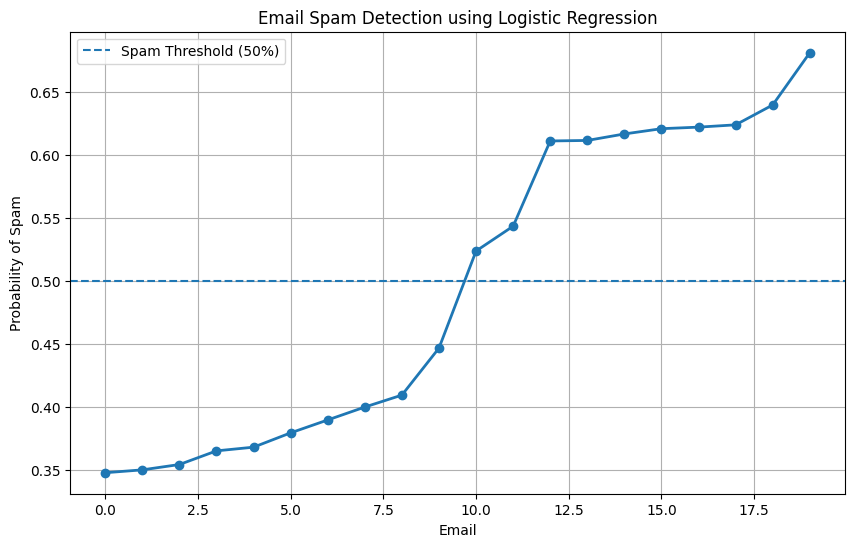


Enter your email message: Thank you for your email

Prediction: NOT SPAM
Spam Probability: 39.98 %


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = pd.read_csv("spam.csv")

# Convert labels
data["Label"] = data["Label"].map({
    "Not Spam": 0,
    "Spam": 1
})

# Input and target
X = data["Email"]
y = data["Label"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text into numerical features
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Create Logistic Regression model
model = LogisticRegression()

# Train model
model.fit(X_train_tfidf, y_train)

# Prediction
y_pred = model.predict(X_test_tfidf)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---------------------------------
# LINE GRAPH
# ---------------------------------

# Predict probability for every email
all_email_features = vectorizer.transform(data["Email"])
probability = model.predict_proba(all_email_features)[:, 1]

# Sort by probability
graph_data = data.copy()
graph_data["Spam Probability"] = probability
graph_data = graph_data.sort_values("Spam Probability")

plt.figure(figsize=(10, 6))

plt.plot(
    range(len(graph_data)),
    graph_data["Spam Probability"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Spam Threshold (50%)"
)

plt.xlabel("Email")
plt.ylabel("Probability of Spam")
plt.title("Email Spam Detection using Logistic Regression")

plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------
# NEW EMAIL PREDICTION
# ---------------------------------

email = input("\nEnter your email message: ")

email_features = vectorizer.transform([email])

prediction = model.predict(email_features)
spam_probability = model.predict_proba(email_features)[0][1]

if prediction[0] == 1:
    print("\nPrediction: SPAM")
else:
    print("\nPrediction: NOT SPAM")

print(
    "Spam Probability:",
    round(spam_probability * 100, 2),
    "%"
)

4. Website Purchase Prediction

Enter time spent on website: 1
Prediction: NO PURCHASE


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


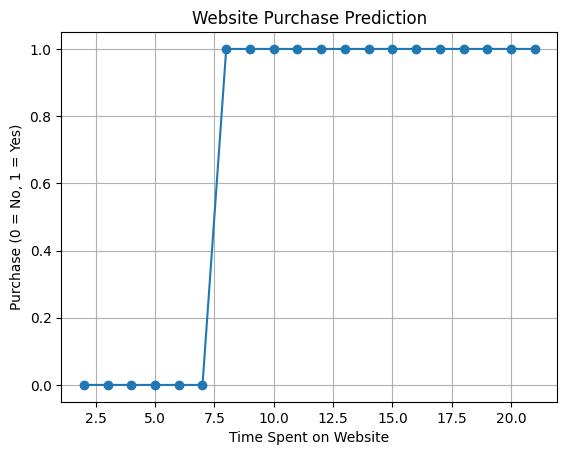

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("website_purchase.csv")

# Input and output
X = data[["Time Spent"]]
y = data["Purchased"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Predict
hours = float(input("Enter time spent on website: "))

prediction = model.predict([[hours]])

if prediction[0] == 1:
    print("Prediction: PURCHASE")
else:
    print("Prediction: NO PURCHASE")

# Graph
plt.plot(data["Time Spent"], y, marker="o")
plt.xlabel("Time Spent on Website")
plt.ylabel("Purchase (0 = No, 1 = Yes)")
plt.title("Website Purchase Prediction")
plt.grid()
plt.show()

5. Employee Promotion Prediction

Enter years of experience: 2
Prediction: NOT PROMOTED


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


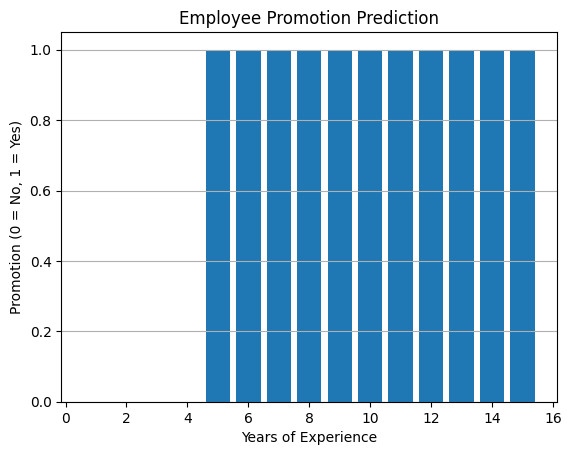

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("employee_promotion.csv")

# Input and output
X = data[["Years of Experience"]]
y = data["Promoted"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
years = float(input("Enter years of experience: "))

# Prediction
prediction = model.predict([[years]])

if prediction[0] == 1:
    print("Prediction: PROMOTED")
else:
    print("Prediction: NOT PROMOTED")

# Bar Graph
plt.bar(
    data["Years of Experience"],
    y
)

plt.xlabel("Years of Experience")
plt.ylabel("Promotion (0 = No, 1 = Yes)")
plt.title("Employee Promotion Prediction")

plt.grid(axis="y")
plt.show()

6. Employee Absenteeism Prediction

Enter previous absences: 12
Prediction: ABSENT


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


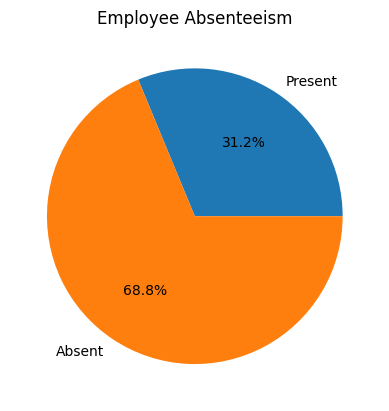

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("employee_absenteeism.csv")

# Input and output
X = data[["Previous Absences"]]
y = data["Absent"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
absences = float(input("Enter previous absences: "))

# Prediction
prediction = model.predict([[absences]])

if prediction[0] == 1:
    print("Prediction: ABSENT")
else:
    print("Prediction: PRESENT")

# Pie Chart
absent_count = sum(y == 1)
present_count = sum(y == 0)

plt.pie(
    [present_count, absent_count],
    labels=["Present", "Absent"],
    autopct="%1.1f%%"
)

plt.title("Employee Absenteeism")
plt.show()

7. Product Return Prediction

Enter number of days product was used: 3
Prediction: PRODUCT WILL BE RETURNED


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


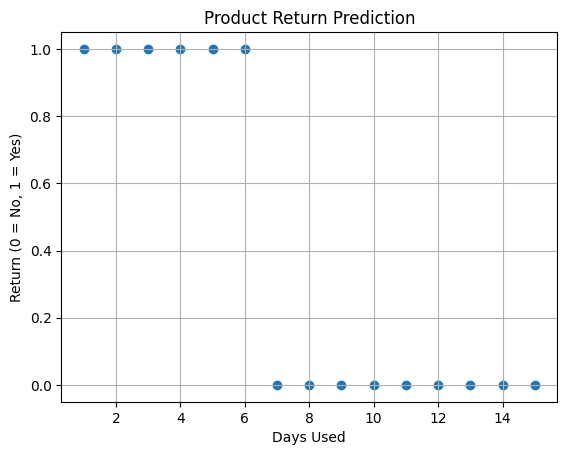

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("product_return.csv")

# Input and output
X = data[["Days Used"]]
y = data["Returned"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
days = float(input("Enter number of days product was used: "))

# Prediction
prediction = model.predict([[days]])

if prediction[0] == 1:
    print("Prediction: PRODUCT WILL BE RETURNED")
else:
    print("Prediction: PRODUCT WILL NOT BE RETURNED")

# Scatter Graph
plt.scatter(
    data["Days Used"],
    y,
    marker="o"
)

plt.xlabel("Days Used")
plt.ylabel("Return (0 = No, 1 = Yes)")
plt.title("Product Return Prediction")
plt.grid()

plt.show()

8. Interview Selection Prediction

Enter interview score: 60


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Prediction: SELECTED


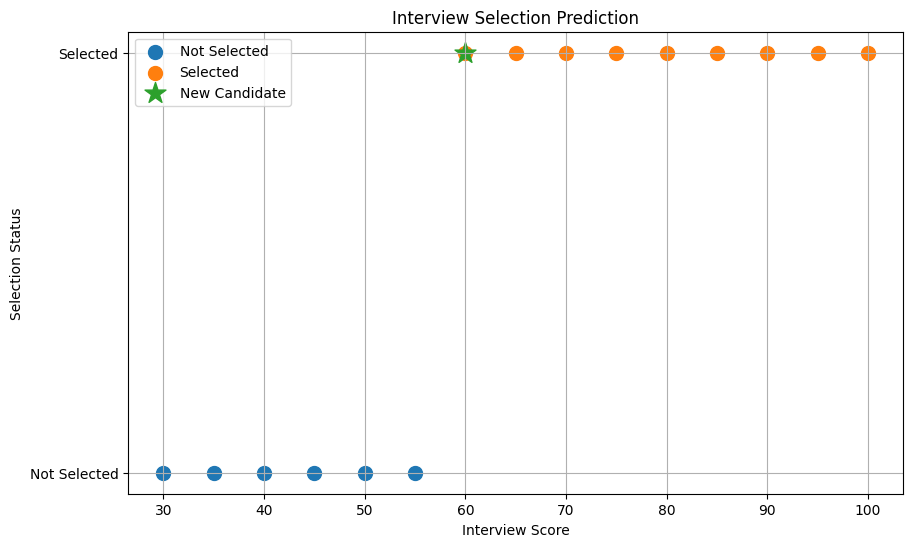

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("interview_selection.csv")

# Input and output
X = data[["Interview Score"]]
y = data["Selected"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
score = float(input("Enter interview score: "))

# Prediction
prediction = model.predict([[score]])

if prediction[0] == 1:
    print("Prediction: SELECTED")
else:
    print("Prediction: NOT SELECTED")

# -----------------------------
# Graph
# -----------------------------

plt.figure(figsize=(10, 6))

# Not Selected candidates
plt.scatter(
    data[data["Selected"] == "No"]["Interview Score"],
    [0] * len(data[data["Selected"] == "No"]),
    label="Not Selected",
    marker="o",
    s=100
)

# Selected candidates
plt.scatter(
    data[data["Selected"] == "Yes"]["Interview Score"],
    [1] * len(data[data["Selected"] == "Yes"]),
    label="Selected",
    marker="o",
    s=100
)

# New candidate
plt.scatter(
    score,
    prediction[0],
    marker="*",
    s=250,
    label="New Candidate"
)

plt.xlabel("Interview Score")
plt.ylabel("Selection Status")
plt.title("Interview Selection Prediction")

plt.yticks(
    [0, 1],
    ["Not Selected", "Selected"]
)

plt.legend()
plt.grid()

plt.show()

9. Job Offer Acceptance

Enter offered salary: 50000
Prediction: JOB OFFER ACCEPTED


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


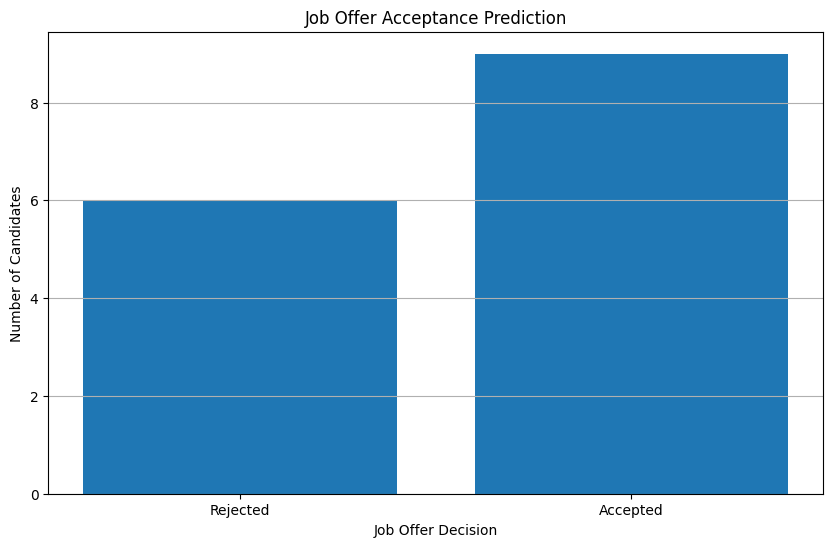

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("job_offer.csv")

# Input and output
X = data[["Offered Salary"]]
y = data["Accepted"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
salary = float(input("Enter offered salary: "))

# Prediction
prediction = model.predict([[salary]])

if prediction[0] == 1:
    print("Prediction: JOB OFFER ACCEPTED")
else:
    print("Prediction: JOB OFFER REJECTED")

# -----------------------------
# Bar Graph
# -----------------------------

plt.figure(figsize=(10, 6))

# Create labels
labels = ["Rejected", "Accepted"]
counts = [
    sum(y == 0),
    sum(y == 1)
]

plt.bar(labels, counts)

plt.xlabel("Job Offer Decision")
plt.ylabel("Number of Candidates")
plt.title("Job Offer Acceptance Prediction")

plt.grid(axis="y")

plt.show()

10. Employee Promotion (Performance Score)

Enter years of experience: 1

Prediction: NOT PROMOTED
Promotion Probability: 1.58 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


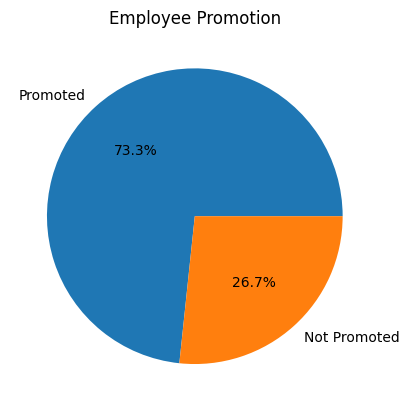

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("employee_promotion.csv")

# Input and output
X = data[["Years of Experience"]]
y = data["Promoted"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
years = float(input("Enter years of experience: "))

# Prediction
prediction = model.predict([[years]])

# Probability score
probability = model.predict_proba([[years]])[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: PROMOTED")
else:
    print("\nPrediction: NOT PROMOTED")

print("Promotion Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Pie Chart
# -----------------------------

promoted = sum(y == 1)
not_promoted = sum(y == 0)

plt.pie(
    [promoted, not_promoted],
    labels=["Promoted", "Not Promoted"],
    autopct="%1.1f%%"
)

plt.title("Employee Promotion")

plt.show()

11. Credit Card Fraud (Transaction Count)

Enter transaction count: 5

Prediction: NOT FRAUD
Fraud Probability: 4.84 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


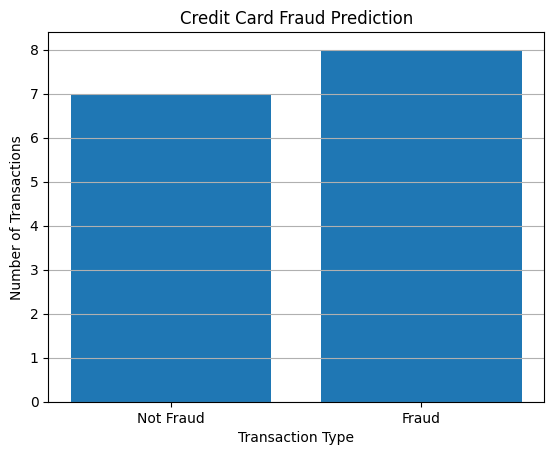

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("credit_card_fraud.csv")

# Input and output
X = data[["Transaction Count"]]
y = data["Fraud"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
transactions = float(input("Enter transaction count: "))

# Prediction
prediction = model.predict([[transactions]])

# Probability score
probability = model.predict_proba([[transactions]])[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: FRAUD")
else:
    print("\nPrediction: NOT FRAUD")

print("Fraud Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Bar Graph
# -----------------------------

fraud = sum(y == 1)
not_fraud = sum(y == 0)

plt.bar(
    ["Not Fraud", "Fraud"],
    [not_fraud, fraud]
)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title("Credit Card Fraud Prediction")

plt.grid(axis="y")

plt.show()

12. Product Recommendation (Like/Dislike)

Enter product rating (1-10): 5

Prediction: DISLIKE
Like Probability: 4.84 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


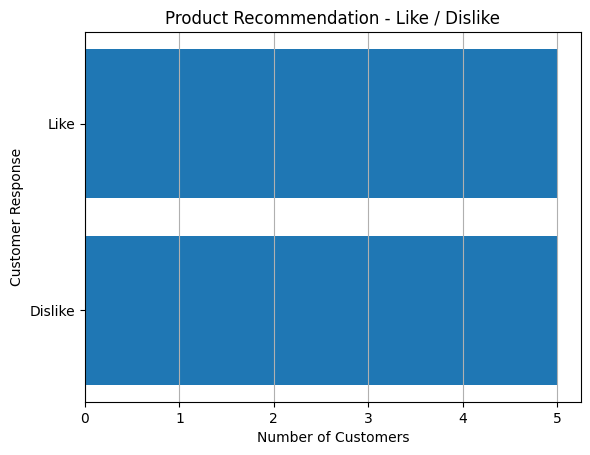

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("product_recommendation.csv")

# Input and output
X = data[["Product Rating"]]
y = data["Like"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
rating = float(input("Enter product rating (1-10): "))

# Prediction
prediction = model.predict([[rating]])


# Result
if prediction[0] == 1:
    print("\nPrediction: LIKE")
else:
    print("\nPrediction: DISLIKE")

print("Like Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Horizontal Bar Graph
# -----------------------------

like = sum(y == 1)
dislike = sum(y == 0)

plt.barh(
    ["Dislike", "Like"],
    [dislike, like]
)

plt.xlabel("Number of Customers")
plt.ylabel("Customer Response")
plt.title("Product Recommendation - Like / Dislike")

plt.grid(axis="x")

plt.show()

13. Customer Complaint Prediction

Enter previous complaints: 6

Prediction: CUSTOMER MAY COMPLAIN
Complaint Probability: 85.67 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


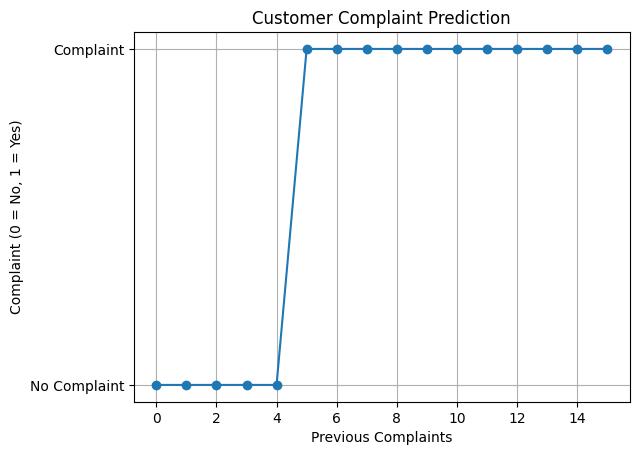

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("customer_complaint.csv")

# Input and output
X = data[["Previous Complaints"]]
y = data["Complaint"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
complaints = float(input("Enter previous complaints: "))

# Prediction
prediction = model.predict([[complaints]])

# Probability score
probability = model.predict_proba([[complaints]])[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: CUSTOMER MAY COMPLAIN")
else:
    print("\nPrediction: CUSTOMER MAY NOT COMPLAIN")

print("Complaint Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Line Graph
# -----------------------------

plt.plot(
    data["Previous Complaints"],
    y,
    marker="o"
)

plt.xlabel("Previous Complaints")
plt.ylabel("Complaint (0 = No, 1 = Yes)")
plt.title("Customer Complaint Prediction")

plt.yticks(
    [0, 1],
    ["No Complaint", "Complaint"]
)

plt.grid()

plt.show()

14. Movie Hit or Flop

Enter movie rating (1-10): 0

Prediction: MOVIE IS A FLOP
Hit Probability: 0.15 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


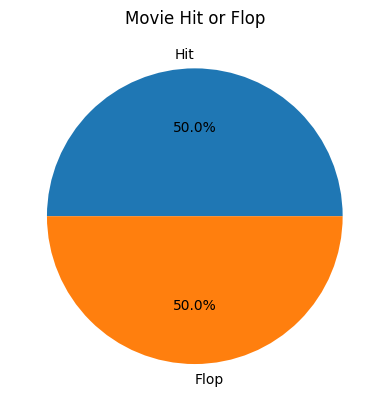

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("movie_hit_flop.csv")

# Input and output
X = data[["Rating"]]
y = data["Result"].map({"Flop": 0, "Hit": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
rating = float(input("Enter movie rating (1-10): "))

# Prediction
prediction = model.predict([[rating]])

# Probability score
probability = model.predict_proba([[rating]])[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: MOVIE IS A HIT")
else:
    print("\nPrediction: MOVIE IS A FLOP")

print("Hit Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Pie Chart
# -----------------------------

hit = sum(y == 1)
flop = sum(y == 0)

plt.pie(
    [hit, flop],
    labels=["Hit", "Flop"],
    autopct="%1.1f%%"
)

plt.title("Movie Hit or Flop")

plt.show()

15. Credit Card Fraud (Transaction Count)

Enter transaction amount: 600

Prediction: NOT FRAUD
Fraud Probability: 0.0 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


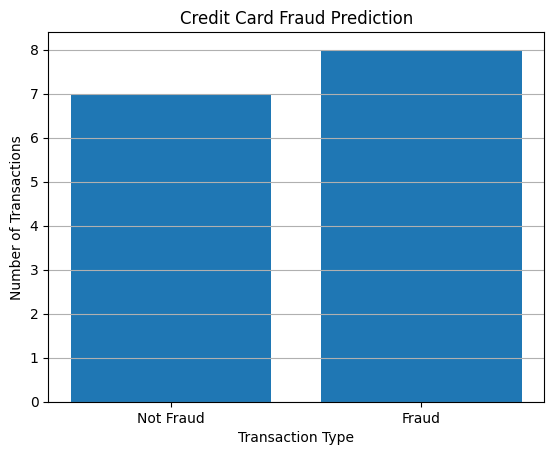

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("credit_card_fraud 1.csv")

# Input and output
X = data[["Transaction Amount"]]
y = data["Fraud"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
amount = float(input("Enter transaction amount: "))

# Prediction
prediction = model.predict([[amount]])

# Probability score
probability = model.predict_proba([[amount]])[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: FRAUD")
else:
    print("\nPrediction: NOT FRAUD")

print("Fraud Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Bar Graph
# -----------------------------

fraud = sum(y == 1)
not_fraud = sum(y == 0)

plt.bar(
    ["Not Fraud", "Fraud"],
    [not_fraud, fraud]
)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title("Credit Card Fraud Prediction")

plt.grid(axis="y")

plt.show()

16. Website Login Success

Enter number of login attempts: 1

Prediction: LOGIN SUCCESS
Login Success Probability: 99.86 %


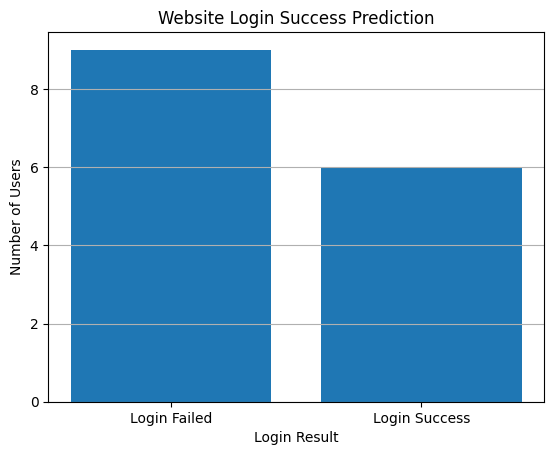

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("website_login.csv")

# Input and output
X = data[["Login Attempts"]]
y = data["Login Success"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
attempts = float(input("Enter number of login attempts: "))

# New data
new_data = pd.DataFrame({
    "Login Attempts": [attempts]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: LOGIN SUCCESS")
else:
    print("\nPrediction: LOGIN FAILED")

print("Login Success Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Bar Graph
# -----------------------------

success = sum(y == 1)
failed = sum(y == 0)

plt.bar(
    ["Login Failed", "Login Success"],
    [failed, success]
)

plt.xlabel("Login Result")
plt.ylabel("Number of Users")
plt.title("Website Login Success Prediction")

plt.grid(axis="y")

plt.show()

17. Food Delivery On-Time

Enter delivery distance (km): 2

Prediction: DELIVERY ON TIME
On-Time Probability: 99.54 %


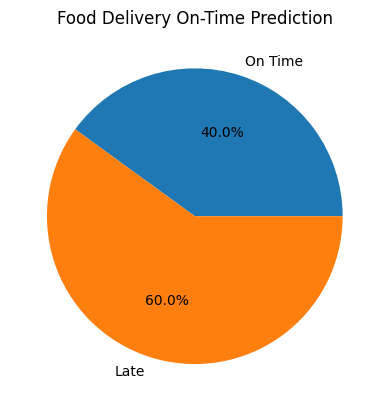

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("food_delivery.csv")

# Input and output
X = data[["Delivery Distance"]]
y = data["On Time"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
distance = float(input("Enter delivery distance (km): "))

# New data
new_data = pd.DataFrame({
    "Delivery Distance": [distance]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: DELIVERY ON TIME")
else:
    print("\nPrediction: DELIVERY WILL BE LATE")

print("On-Time Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Pie Chart
# -----------------------------

on_time = sum(y == 1)
late = sum(y == 0)

plt.pie(
    [on_time, late],
    labels=["On Time", "Late"],
    autopct="%1.1f%%"
)

plt.title("Food Delivery On-Time Prediction")

plt.show()

18. Insurance Policy Renewal

Enter years with company: 1

Prediction: POLICY WILL NOT BE RENEWED
Renewal Probability: 1.58 %


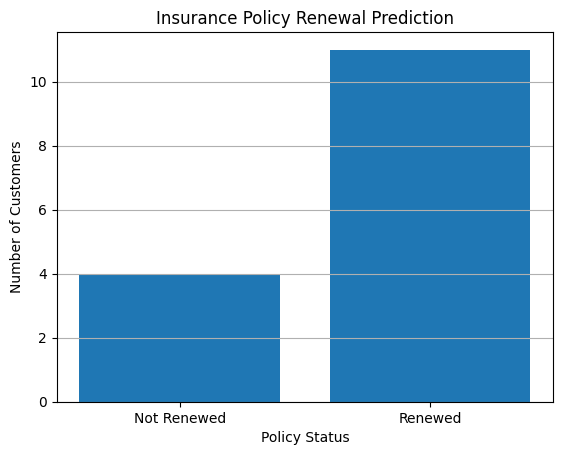

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("insurance_renewal.csv")

# Input and output
X = data[["Years With Company"]]
y = data["Renewed"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
years = float(input("Enter years with company: "))

# New data
new_data = pd.DataFrame({
    "Years With Company": [years]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: POLICY WILL BE RENEWED")
else:
    print("\nPrediction: POLICY WILL NOT BE RENEWED")

print("Renewal Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Bar Graph
# -----------------------------

renewed = sum(y == 1)
not_renewed = sum(y == 0)

plt.bar(
    ["Not Renewed", "Renewed"],
    [not_renewed, renewed]
)

plt.xlabel("Policy Status")
plt.ylabel("Number of Customers")
plt.title("Insurance Policy Renewal Prediction")

plt.grid(axis="y")

plt.show()

19. Interview Attendance

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("interview_attendance.csv")

# Input and output
X = data[["Previous Interviews"]]
y = data["Attended"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
interviews = float(input("Enter previous interviews attended: "))

# New data
new_data = pd.DataFrame({
    "Previous Interviews": [interviews]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: INTERVIEW ATTEND")
else:
    print("\nPrediction: INTERVIEW NOT ATTEND")

print("Attendance Probability:", round(probability * 100, 2), "%")

Enter previous interviews attended: 1

Prediction: INTERVIEW NOT ATTEND
Attendance Probability: 1.53 %


20. Restaurant Rating (Good/Bad)

Enter restaurant rating (1-10): 1

Prediction: RESTAURANT RATING IS BAD
Good Rating Probability: 0.48 %


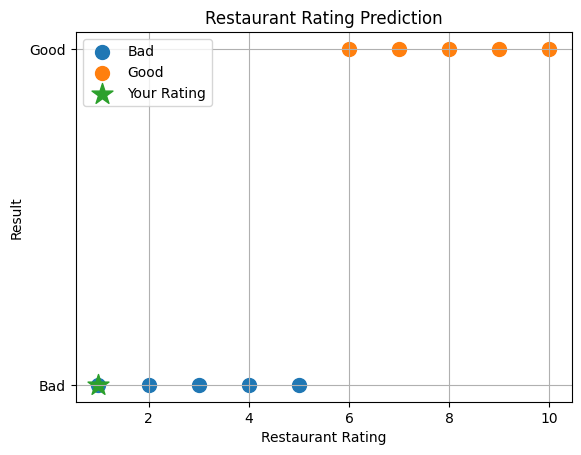

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("restaurant_rating.csv")

# Input and output
X = data[["Rating"]]
y = data["Result"].map({"Bad": 0, "Good": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
rating = float(input("Enter restaurant rating (1-10): "))

# New data
new_data = pd.DataFrame({
    "Rating": [rating]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: RESTAURANT RATING IS GOOD")
else:
    print("\nPrediction: RESTAURANT RATING IS BAD")

print("Good Rating Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Scatter Graph
# -----------------------------

good = data[data["Result"] == "Good"]
bad = data[data["Result"] == "Bad"]

plt.scatter(
    bad["Rating"],
    [0] * len(bad),
    label="Bad",
    s=100
)

plt.scatter(
    good["Rating"],
    [1] * len(good),
    label="Good",
    s=100
)

# New prediction
plt.scatter(
    rating,
    prediction[0],
    marker="*",
    s=250,
    label="Your Rating"
)

plt.xlabel("Restaurant Rating")
plt.ylabel("Result")
plt.title("Restaurant Rating Prediction")

plt.yticks(
    [0, 1],
    ["Bad", "Good"]
)

plt.legend()
plt.grid()

plt.show()

21. Subscription Cancellation

Enter months subscribed: 2

Prediction: SUBSCRIPTION WILL BE CANCELLED
Cancellation Probability: 98.47 %


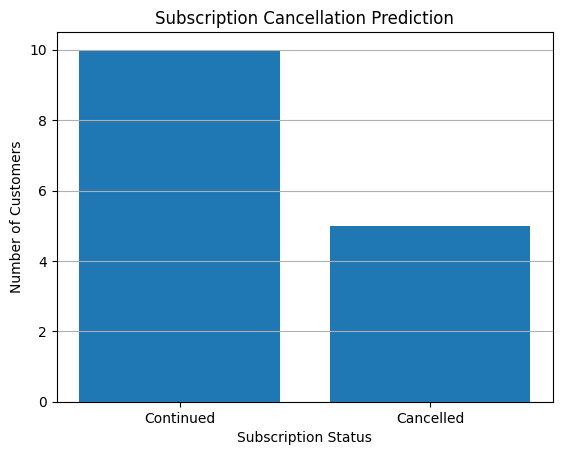

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("subscription_cancellation.csv")

# Input and output
X = data[["Months Subscribed"]]
y = data["Canceled"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
months = float(input("Enter months subscribed: "))

# New data
new_data = pd.DataFrame({
    "Months Subscribed": [months]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: SUBSCRIPTION WILL BE CANCELLED")
else:
    print("\nPrediction: SUBSCRIPTION WILL CONTINUE")

print("Cancellation Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Bar Graph
# -----------------------------

canceled = sum(y == 1)
continued = sum(y == 0)

plt.bar(
    ["Continued", "Cancelled"],
    [continued, canceled]
)

plt.xlabel("Subscription Status")
plt.ylabel("Number of Customers")
plt.title("Subscription Cancellation Prediction")

plt.grid(axis="y")

plt.show()

22. Product Defect Detection

Enter defect score (1-10): 9

Prediction: PRODUCT IS DEFECTIVE
Defect Probability: 98.45 %


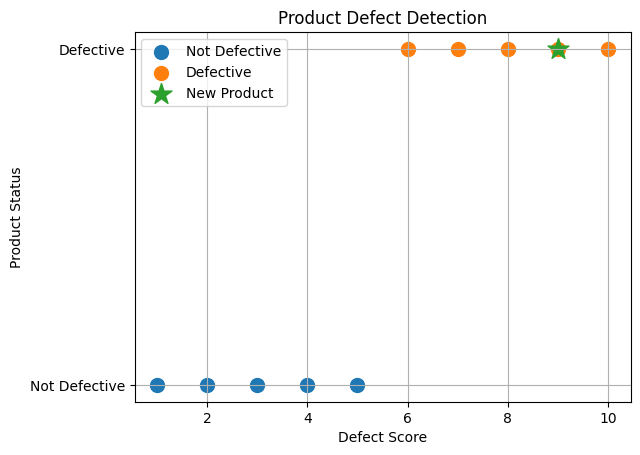

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("product_defect.csv")

# Input and output
X = data[["Defect Score"]]
y = data["Defective"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
score = float(input("Enter defect score (1-10): "))

# New data
new_data = pd.DataFrame({
    "Defect Score": [score]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: PRODUCT IS DEFECTIVE")
else:
    print("\nPrediction: PRODUCT IS NOT DEFECTIVE")

print("Defect Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Scatter Graph
# -----------------------------

not_defective = data[data["Defective"] == "No"]
defective = data[data["Defective"] == "Yes"]

plt.scatter(
    not_defective["Defect Score"],
    [0] * len(not_defective),
    label="Not Defective",
    s=100
)

plt.scatter(
    defective["Defect Score"],
    [1] * len(defective),
    label="Defective",
    s=100
)

# New prediction
plt.scatter(
    score,
    prediction[0],
    marker="*",
    s=250,
    label="New Product"
)

plt.xlabel("Defect Score")
plt.ylabel("Product Status")
plt.title("Product Defect Detection")

plt.yticks(
    [0, 1],
    ["Not Defective", "Defective"]
)

plt.legend()
plt.grid()

plt.show()

23. App Crash Detection

Enter app usage hours: 6

Prediction: APP MAY CRASH
Crash Probability: 64.5 %


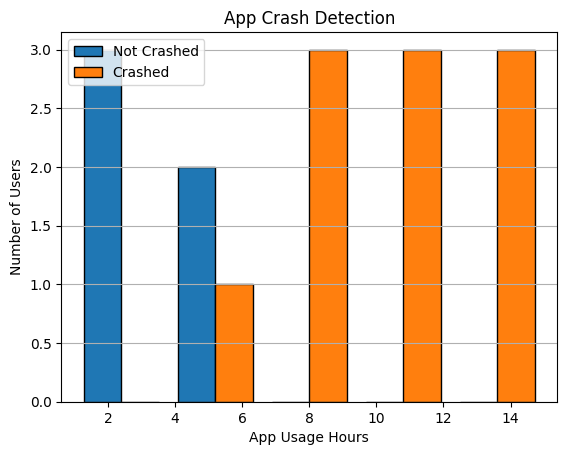

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("app_crash.csv")

# Input and output
X = data[["Usage Hours"]]
y = data["Crashed"].map({"No": 0, "Yes": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
hours = float(input("Enter app usage hours: "))

# New data
new_data = pd.DataFrame({
    "Usage Hours": [hours]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: APP MAY CRASH")
else:
    print("\nPrediction: APP MAY NOT CRASH")

print("Crash Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Histogram
# -----------------------------

crashed = data[data["Crashed"] == "Yes"]["Usage Hours"]
not_crashed = data[data["Crashed"] == "No"]["Usage Hours"]

plt.hist(
    [not_crashed, crashed],
    bins=5,
    label=["Not Crashed", "Crashed"],
    edgecolor="black"
)

plt.xlabel("App Usage Hours")
plt.ylabel("Number of Users")
plt.title("App Crash Detection")

plt.legend()
plt.grid(axis="y")

plt.show()

24. Customer Feedback Positive (Rating)

Enter customer rating (1-10): 8

Prediction: POSITIVE FEEDBACK
Positive Feedback Probability: 95.1 %


/tmp/ipykernel_2463/1810231072.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


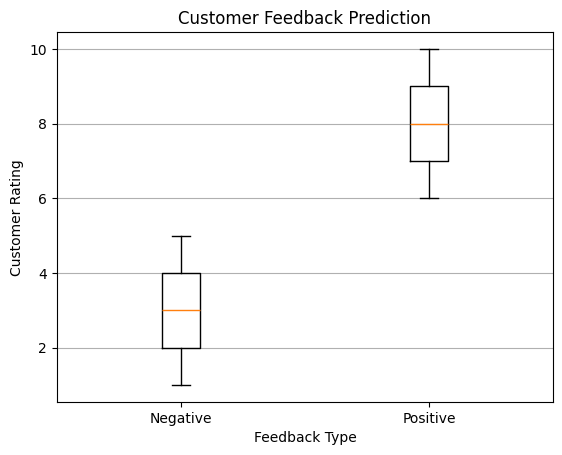

Enter customer rating (1-10): 8

Prediction: POSITIVE FEEDBACK
Positive Feedback Probability: 95.1 %


/tmp/ipykernel_2463/1810231072.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


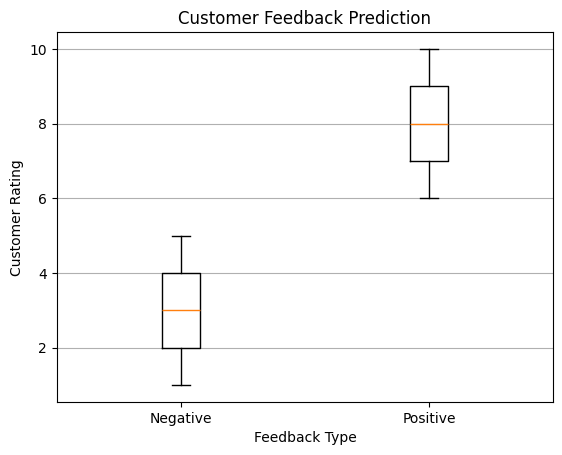

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("customer_feedback.csv")

# Input and output
X = data[["Rating"]]
y = data["Feedback"].map({"Negative": 0, "Positive": 1})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
rating = float(input("Enter customer rating (1-10): "))

# New data
new_data = pd.DataFrame({
    "Rating": [rating]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: POSITIVE FEEDBACK")
else:
    print("\nPrediction: NEGATIVE FEEDBACK")

print("Positive Feedback Probability:", round(probability * 100, 2), "%")

# -----------------------------
# Box Plot
# -----------------------------

positive = data[data["Feedback"] == "Positive"]["Rating"]
negative = data[data["Feedback"] == "Negative"]["Rating"]

plt.boxplot(
    [negative, positive],
    labels=["Negative", "Positive"]
)

plt.xlabel("Feedback Type")
plt.ylabel("Customer Rating")
plt.title("Customer Feedback Prediction")

plt.grid(axis="y")

plt.show()

25. ATM Cash Availability

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("atm_cash.csv")

# Input and output
X = data[["Withdrawals"]]
y = data["Cash Available"].map({
    "No": 0,
    "Yes": 1
})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
withdrawals = float(input("Enter number of withdrawals: "))

# New ATM data
new_data = pd.DataFrame({
    "Withdrawals": [withdrawals]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: CASH AVAILABLE")
else:
    print("\nPrediction: CASH NOT AVAILABLE")

print(
    "Cash Availability Probability:",
    round(probability * 100, 2),
    "%"
)

Enter number of withdrawals: 10

Prediction: CASH NOT AVAILABLE
Cash Availability Probability: 1.51 %


26. Online Exam Passed

In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("online_exam.csv")

# Input and output
X = data[["Study Hours"]]

y = data["Exam Result"].map({
    "Fail": 0,
    "Pass": 1
})

# Train model
model = LogisticRegression()
model.fit(X, y)

# Take input
study_hours = float(input("Enter study hours: "))

# New student data
new_data = pd.DataFrame({
    "Study Hours": [study_hours]
})

# Prediction
prediction = model.predict(new_data)

# Probability score
probability = model.predict_proba(new_data)[0][1]

# Result
if prediction[0] == 1:
    print("\nPrediction: EXAM PASSED")
else:
    print("\nPrediction: EXAM NOT PASSED")

print(
    "Pass Probability:",
    round(probability * 100, 2),
    "%"
)

Enter study hours: 6

Prediction: EXAM PASSED
Pass Probability: 80.64 %


27. Online Payment Success


ONLINE PAYMENT PREDICTION
Model Accuracy: 91.0 %

Enter payment details:
Enter transaction amount: ₹500000
Enter account balance: ₹1000000
Enter number of transactions today: 500000
Enter customer age: 27
Enter previous failed attempts: 5

Prediction: PAYMENT SUCCESSFUL
Payment Success Probability: 100.0 %


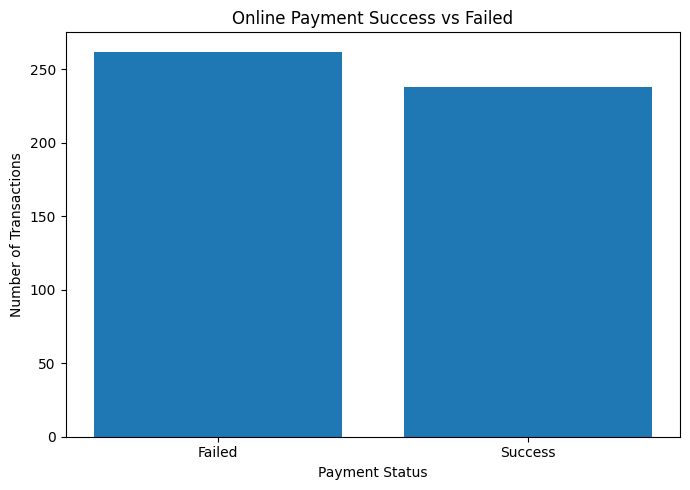

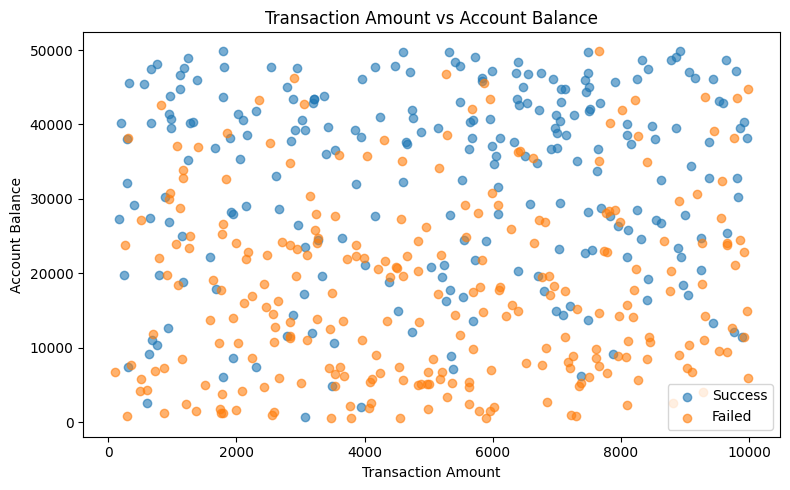

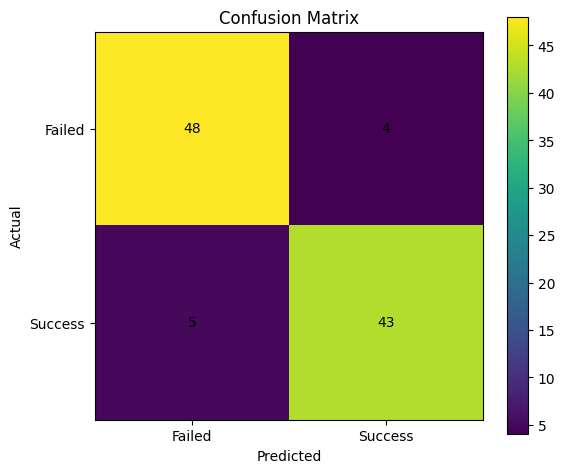


Project completed successfully.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ---------------------------------------------------
# 1. CREATE BUILT-IN DATA
# ---------------------------------------------------

np.random.seed(42)

n = 500

transaction_amount = np.random.randint(100, 10000, n)
account_balance = np.random.randint(500, 50000, n)
transaction_count = np.random.randint(1, 15, n)
customer_age = np.random.randint(18, 65, n)
failed_attempts = np.random.randint(0, 5, n)

# Create payment success condition
score = (
    account_balance * 0.00008
    + transaction_count * 0.15
    + customer_age * 0.02
    - transaction_amount * 0.00004
    - failed_attempts * 0.8
    + np.random.normal(0, 0.8, n)
)

payment_success = np.where(score > 2.2, "Success", "Failed")

data = pd.DataFrame({
    "Transaction Amount": transaction_amount,
    "Account Balance": account_balance,
    "Transaction Count": transaction_count,
    "Customer Age": customer_age,
    "Failed Attempts": failed_attempts,
    "Payment Status": payment_success
})

# ---------------------------------------------------
# 2. INPUT AND OUTPUT
# ---------------------------------------------------

features = [
    "Transaction Amount",
    "Account Balance",
    "Transaction Count",
    "Customer Age",
    "Failed Attempts"
]

X = data[features]

y = data["Payment Status"].map({
    "Failed": 0,
    "Success": 1
})

# ---------------------------------------------------
# 3. TRAIN MODEL
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# ---------------------------------------------------
# 4. MODEL ACCURACY
# ---------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("ONLINE PAYMENT PREDICTION")
print("==============================")

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

# ---------------------------------------------------
# 5. TAKE USER INPUT
# ---------------------------------------------------

print("\nEnter payment details:")

amount = float(input("Enter transaction amount: ₹"))
balance = float(input("Enter account balance: ₹"))
transactions = int(input("Enter number of transactions today: "))
age = int(input("Enter customer age: "))
failed = int(input("Enter previous failed attempts: "))

# ---------------------------------------------------
# 6. NEW PAYMENT DATA
# ---------------------------------------------------

new_data = pd.DataFrame({
    "Transaction Amount": [amount],
    "Account Balance": [balance],
    "Transaction Count": [transactions],
    "Customer Age": [age],
    "Failed Attempts": [failed]
})

# ---------------------------------------------------
# 7. PREDICTION
# ---------------------------------------------------

prediction = model.predict(new_data)

# Probability of successful payment
probability = model.predict_proba(new_data)[0][1]

# ---------------------------------------------------
# 8. RESULT
# ---------------------------------------------------

if prediction[0] == 1:

    print("\nPrediction: PAYMENT SUCCESSFUL")

else:

    print("\nPrediction: PAYMENT FAILED")


print(
    "Payment Success Probability:",
    round(probability * 100, 2),
    "%"
)

# ---------------------------------------------------
# 9. GRAPH 1 - PAYMENT SUCCESS VS FAILED
# ---------------------------------------------------

status_counts = data["Payment Status"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Online Payment Success vs Failed")
plt.xlabel("Payment Status")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 10. GRAPH 2 - TRANSACTION AMOUNT VS ACCOUNT BALANCE
# ---------------------------------------------------

plt.figure(figsize=(8, 5))

success_data = data[data["Payment Status"] == "Success"]
failed_data = data[data["Payment Status"] == "Failed"]

plt.scatter(
    success_data["Transaction Amount"],
    success_data["Account Balance"],
    label="Success",
    alpha=0.6
)

plt.scatter(
    failed_data["Transaction Amount"],
    failed_data["Account Balance"],
    label="Failed",
    alpha=0.6
)

plt.title("Transaction Amount vs Account Balance")
plt.xlabel("Transaction Amount")
plt.ylabel("Account Balance")
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 11. GRAPH 3 - CONFUSION MATRIX
# ---------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Failed", "Success"]
)

plt.yticks(
    [0, 1],
    ["Failed", "Success"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

print("\nProject completed successfully.")

28. Vaccine Effectiveness Prediction


VACCINE EFFECTIVENESS PREDICTION
Model Accuracy: 91.0 %

Enter vaccination details:
Enter age: 67
Enter number of vaccine doses: 45
Enter days after vaccination: 56
Previous infection? (1 = Yes, 0 = No): 0
Enter health score (40-100): 56

Prediction: VACCINE EFFECTIVE
Effectiveness Probability: 100.0 %


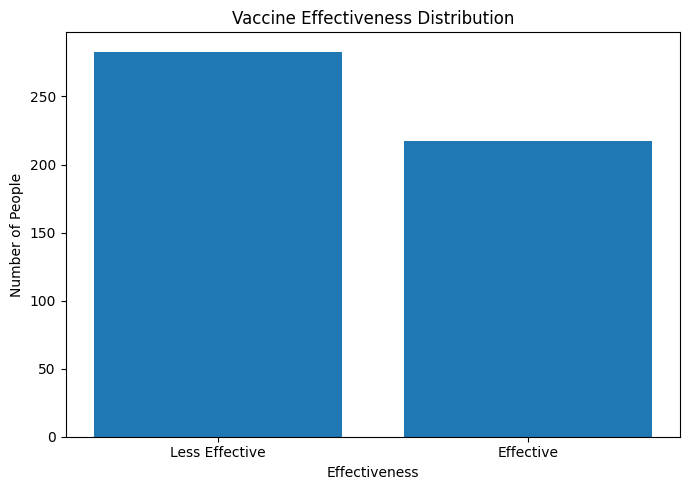

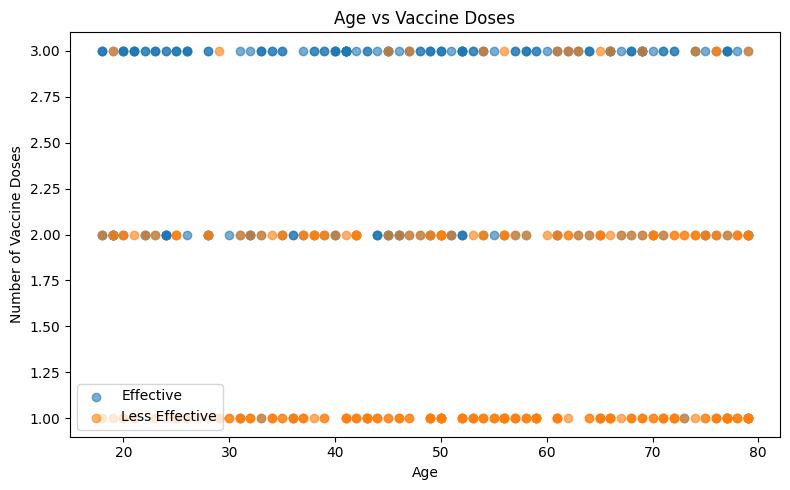

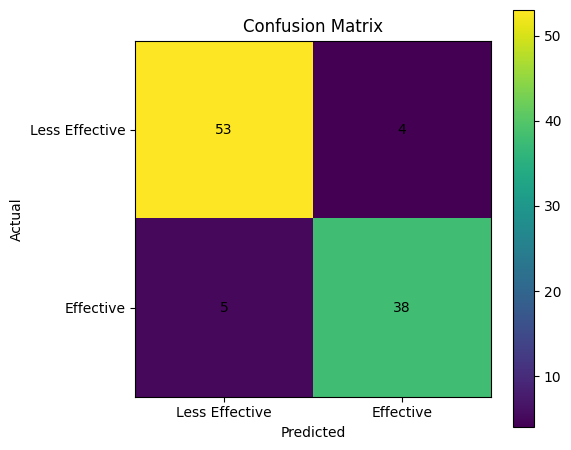


Project completed successfully.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


# ---------------------------------------------------
# 1. CREATE BUILT-IN DATA
# ---------------------------------------------------

np.random.seed(42)

n = 500

age = np.random.randint(18, 80, n)
doses = np.random.randint(1, 4, n)
days_after_vaccine = np.random.randint(14, 365, n)
previous_infection = np.random.randint(0, 2, n)
health_score = np.random.randint(40, 101, n)

# Synthetic effectiveness score
score = (
    doses * 1.5
    + health_score * 0.025
    + days_after_vaccine * 0.001
    - age * 0.015
    - previous_infection * 0.8
    + np.random.normal(0, 0.8, n)
)

effectiveness = np.where(
    score >= 4.0,
    "Effective",
    "Less Effective"
)

data = pd.DataFrame({
    "Age": age,
    "Vaccine Doses": doses,
    "Days After Vaccine": days_after_vaccine,
    "Previous Infection": previous_infection,
    "Health Score": health_score,
    "Vaccine Effectiveness": effectiveness
})


# ---------------------------------------------------
# 2. INPUT AND OUTPUT
# ---------------------------------------------------

features = [
    "Age",
    "Vaccine Doses",
    "Days After Vaccine",
    "Previous Infection",
    "Health Score"
]

X = data[features]

y = data["Vaccine Effectiveness"].map({
    "Less Effective": 0,
    "Effective": 1
})


# ---------------------------------------------------
# 3. TRAIN MODEL
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# ---------------------------------------------------
# 4. MODEL ACCURACY
# ---------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("VACCINE EFFECTIVENESS PREDICTION")
print("===================================")

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# ---------------------------------------------------
# 5. TAKE USER INPUT
# ---------------------------------------------------

print("\nEnter vaccination details:")

person_age = int(
    input("Enter age: ")
)

person_doses = int(
    input("Enter number of vaccine doses: ")
)

person_days = int(
    input("Enter days after vaccination: ")
)

person_previous_infection = int(
    input("Previous infection? (1 = Yes, 0 = No): ")
)

person_health_score = int(
    input("Enter health score (40-100): ")
)


# ---------------------------------------------------
# 6. NEW PERSON DATA
# ---------------------------------------------------

new_data = pd.DataFrame({
    "Age": [person_age],
    "Vaccine Doses": [person_doses],
    "Days After Vaccine": [person_days],
    "Previous Infection": [person_previous_infection],
    "Health Score": [person_health_score]
})


# ---------------------------------------------------
# 7. PREDICTION
# ---------------------------------------------------

prediction = model.predict(new_data)

probability = model.predict_proba(new_data)[0][1]


# ---------------------------------------------------
# 8. RESULT
# ---------------------------------------------------

if prediction[0] == 1:

    print("\nPrediction: VACCINE EFFECTIVE")

else:

    print("\nPrediction: LESS EFFECTIVE")


print(
    "Effectiveness Probability:",
    round(probability * 100, 2),
    "%"
)


# ---------------------------------------------------
# 9. GRAPH 1
# EFFECTIVE VS LESS EFFECTIVE
# ---------------------------------------------------

status_counts = data[
    "Vaccine Effectiveness"
].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title(
    "Vaccine Effectiveness Distribution"
)

plt.xlabel(
    "Effectiveness"
)

plt.ylabel(
    "Number of People"
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------
# 10. GRAPH 2
# AGE VS VACCINE DOSES
# ---------------------------------------------------

effective_data = data[
    data["Vaccine Effectiveness"] == "Effective"
]

less_effective_data = data[
    data["Vaccine Effectiveness"] == "Less Effective"
]

plt.figure(figsize=(8, 5))

plt.scatter(
    effective_data["Age"],
    effective_data["Vaccine Doses"],
    label="Effective",
    alpha=0.6
)

plt.scatter(
    less_effective_data["Age"],
    less_effective_data["Vaccine Doses"],
    label="Less Effective",
    alpha=0.6
)

plt.title(
    "Age vs Vaccine Doses"
)

plt.xlabel(
    "Age"
)

plt.ylabel(
    "Number of Vaccine Doses"
)

plt.legend()

plt.tight_layout()

plt.show()


# ---------------------------------------------------
# 11. GRAPH 3
# CONFUSION MATRIX
# ---------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Less Effective", "Effective"]
)

plt.yticks(
    [0, 1],
    ["Less Effective", "Effective"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()


print("\nProject completed successfully.")

29. Online Course Completion


ONLINE COURSE COMPLETION
PREDICTION
Model Accuracy: 92.0 %

Enter student course details:
Enter study hours per week: 12
Enter video completion percentage: 34
Enter average quiz score: 59
Enter completed assignments: 56
Enter login days per month: 15

Prediction: COURSE COMPLETED
Course Completion Probability: 100.0 %


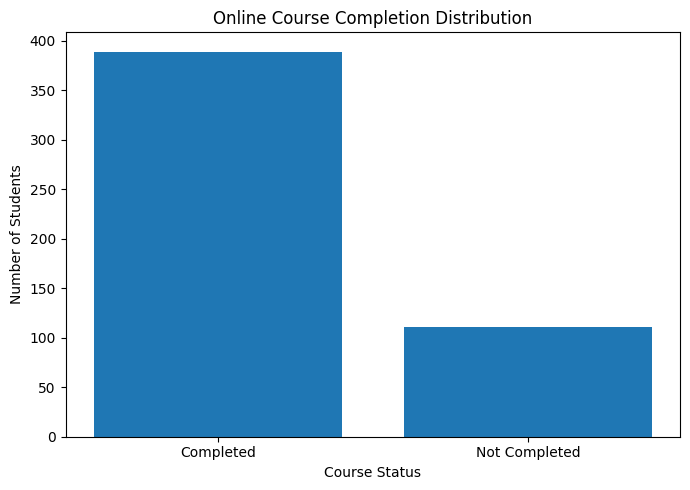

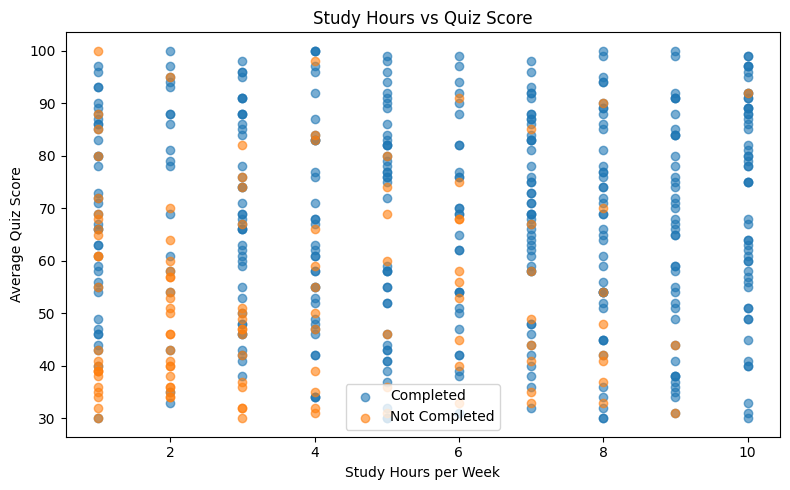

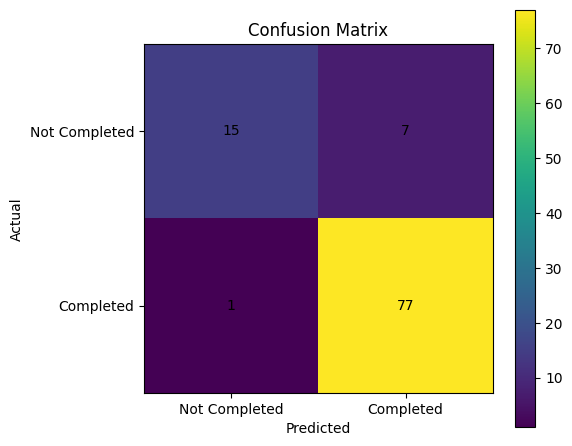


Project completed successfully.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


# ---------------------------------------------------
# 1. CREATE BUILT-IN DATA
# ---------------------------------------------------

np.random.seed(42)

n = 500

study_hours = np.random.randint(1, 11, n)
video_completion = np.random.randint(20, 101, n)
quiz_score = np.random.randint(30, 101, n)
assignments = np.random.randint(0, 11, n)
login_days = np.random.randint(1, 31, n)

# Synthetic course completion score
score = (
    study_hours * 0.35
    + video_completion * 0.025
    + quiz_score * 0.025
    + assignments * 0.25
    + login_days * 0.08
    + np.random.normal(0, 1, n)
)

course_completion = np.where(
    score >= 6.0,
    "Completed",
    "Not Completed"
)

data = pd.DataFrame({
    "Study Hours": study_hours,
    "Video Completion": video_completion,
    "Quiz Score": quiz_score,
    "Assignments": assignments,
    "Login Days": login_days,
    "Course Completion": course_completion
})


# ---------------------------------------------------
# 2. INPUT AND OUTPUT
# ---------------------------------------------------

features = [
    "Study Hours",
    "Video Completion",
    "Quiz Score",
    "Assignments",
    "Login Days"
]

X = data[features]

y = data["Course Completion"].map({
    "Not Completed": 0,
    "Completed": 1
})


# ---------------------------------------------------
# 3. TRAIN MODEL
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# ---------------------------------------------------
# 4. MODEL ACCURACY
# ---------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n===================================")
print("ONLINE COURSE COMPLETION")
print("PREDICTION")
print("===================================")

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# ---------------------------------------------------
# 5. TAKE USER INPUT
# ---------------------------------------------------

print("\nEnter student course details:")

student_study_hours = float(
    input("Enter study hours per week: ")
)

student_video_completion = float(
    input("Enter video completion percentage: ")
)

student_quiz_score = float(
    input("Enter average quiz score: ")
)

student_assignments = int(
    input("Enter completed assignments: ")
)

student_login_days = int(
    input("Enter login days per month: ")
)


# ---------------------------------------------------
# 6. NEW STUDENT DATA
# ---------------------------------------------------

new_data = pd.DataFrame({
    "Study Hours": [student_study_hours],
    "Video Completion": [student_video_completion],
    "Quiz Score": [student_quiz_score],
    "Assignments": [student_assignments],
    "Login Days": [student_login_days]
})


# ---------------------------------------------------
# 7. PREDICTION
# ---------------------------------------------------

prediction = model.predict(new_data)

probability = model.predict_proba(new_data)[0][1]


# ---------------------------------------------------
# 8. RESULT
# ---------------------------------------------------

if prediction[0] == 1:

    print("\nPrediction: COURSE COMPLETED")

else:

    print("\nPrediction: COURSE NOT COMPLETED")


print(
    "Course Completion Probability:",
    round(probability * 100, 2),
    "%"
)


# ---------------------------------------------------
# 9. GRAPH 1
# COMPLETED VS NOT COMPLETED
# ---------------------------------------------------

completion_counts = data[
    "Course Completion"
].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    completion_counts.index,
    completion_counts.values
)

plt.title(
    "Online Course Completion Distribution"
)

plt.xlabel(
    "Course Status"
)

plt.ylabel(
    "Number of Students"
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------
# 10. GRAPH 2
# STUDY HOURS VS QUIZ SCORE
# ---------------------------------------------------

completed_data = data[
    data["Course Completion"] == "Completed"
]

not_completed_data = data[
    data["Course Completion"] == "Not Completed"
]

plt.figure(figsize=(8, 5))

plt.scatter(
    completed_data["Study Hours"],
    completed_data["Quiz Score"],
    label="Completed",
    alpha=0.6
)

plt.scatter(
    not_completed_data["Study Hours"],
    not_completed_data["Quiz Score"],
    label="Not Completed",
    alpha=0.6
)

plt.title(
    "Study Hours vs Quiz Score"
)

plt.xlabel(
    "Study Hours per Week"
)

plt.ylabel(
    "Average Quiz Score"
)

plt.legend()

plt.tight_layout()

plt.show()


# ---------------------------------------------------
# 11. GRAPH 3
# CONFUSION MATRIX
# ---------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Not Completed", "Completed"]
)

plt.yticks(
    [0, 1],
    ["Not Completed", "Completed"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()


print("\nProject completed successfully.")

30. Social Media Addiction Detection


SOCIAL MEDIA USAGE DETECTION
Model Accuracy: 94.0 %

Enter user information:
Enter age: 56
Enter daily screen time (hours): 8
Enter social media usage (hours): 5
Enter notifications received per day: 89
Enter average sleep hours: 8
Enter weekend social media usage (hours): 10

Prediction: NORMAL SOCIAL MEDIA USAGE
High Usage Probability: 26.55 %


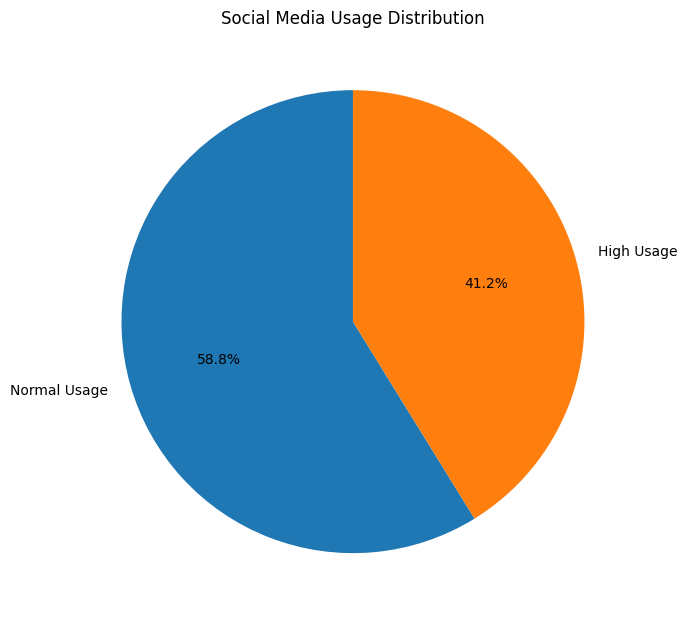

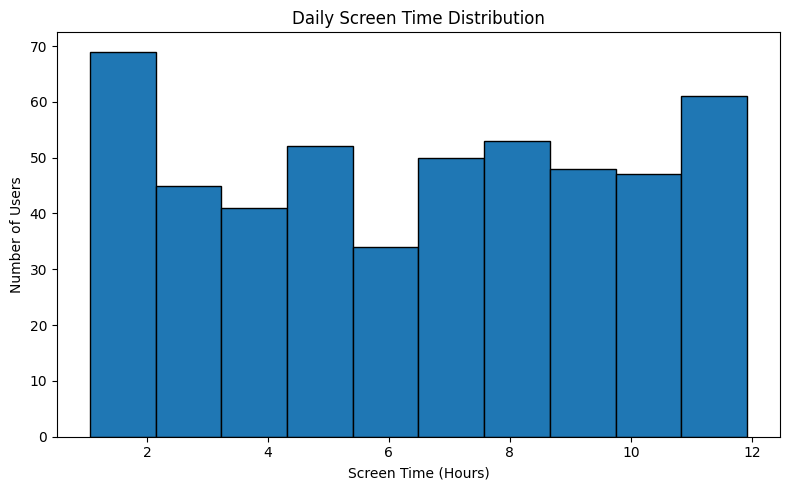

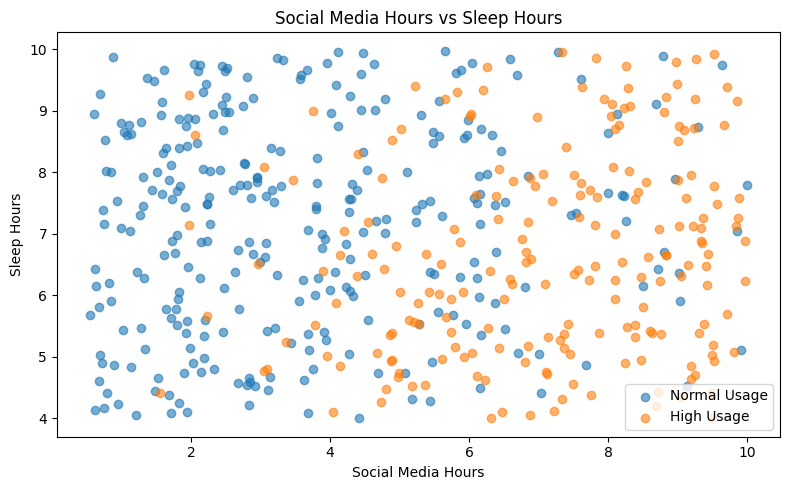

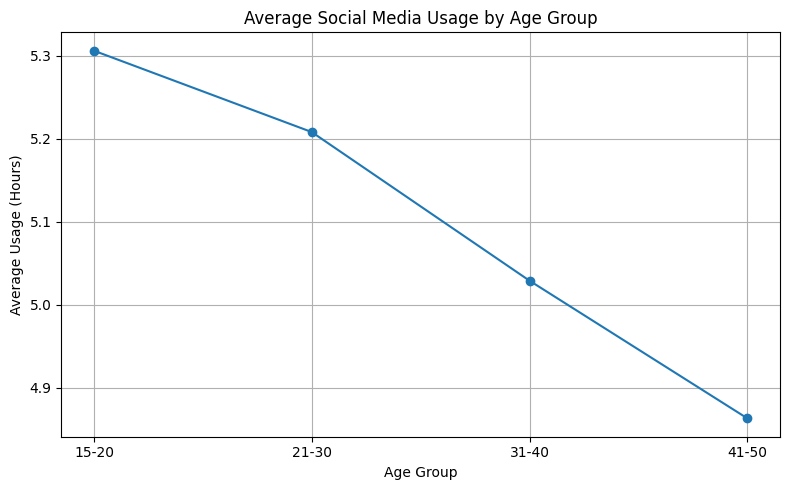

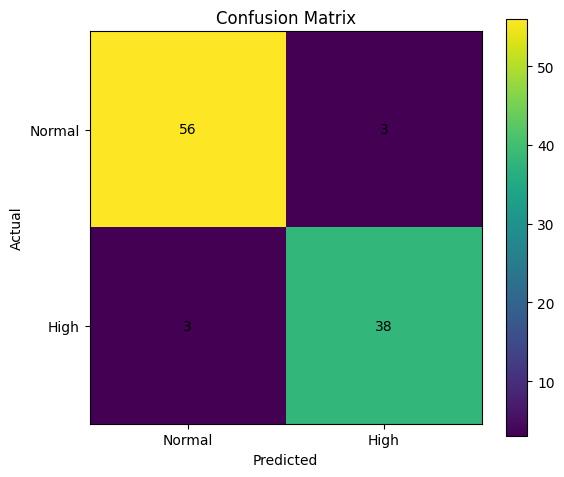


Project completed successfully.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


# =====================================================
# 1. CREATE BUILT-IN DATA
# =====================================================

np.random.seed(42)

n = 500

daily_screen_time = np.random.uniform(1, 12, n)
social_media_hours = np.random.uniform(0.5, 10, n)
notifications = np.random.randint(10, 201, n)
sleep_hours = np.random.uniform(4, 10, n)
age = np.random.randint(15, 50, n)
weekend_usage = np.random.uniform(1, 14, n)


# Synthetic addiction score
addiction_score = (
    social_media_hours * 0.75
    + daily_screen_time * 0.30
    + notifications * 0.015
    - sleep_hours * 0.35
    + weekend_usage * 0.20
    + np.random.normal(0, 1.2, n)
)

addiction = np.where(
    addiction_score >= 7,
    "High Usage",
    "Normal Usage"
)


data = pd.DataFrame({
    "Age": age,
    "Daily Screen Time": daily_screen_time,
    "Social Media Hours": social_media_hours,
    "Notifications": notifications,
    "Sleep Hours": sleep_hours,
    "Weekend Usage": weekend_usage,
    "Addiction Level": addiction
})


# =====================================================
# 2. INPUT AND OUTPUT
# =====================================================

features = [
    "Age",
    "Daily Screen Time",
    "Social Media Hours",
    "Notifications",
    "Sleep Hours",
    "Weekend Usage"
]

X = data[features]

y = data["Addiction Level"].map({
    "Normal Usage": 0,
    "High Usage": 1
})


# =====================================================
# 3. TRAIN MODEL
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# =====================================================
# 4. MODEL ACCURACY
# =====================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n======================================")
print("SOCIAL MEDIA USAGE DETECTION")
print("======================================")

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# =====================================================
# 5. TAKE USER INPUT
# =====================================================

print("\nEnter user information:")

user_age = int(
    input("Enter age: ")
)

user_screen_time = float(
    input("Enter daily screen time (hours): ")
)

user_social_hours = float(
    input("Enter social media usage (hours): ")
)

user_notifications = int(
    input("Enter notifications received per day: ")
)

user_sleep = float(
    input("Enter average sleep hours: ")
)

user_weekend = float(
    input("Enter weekend social media usage (hours): ")
)


# =====================================================
# 6. NEW USER DATA
# =====================================================

new_data = pd.DataFrame({
    "Age": [user_age],
    "Daily Screen Time": [user_screen_time],
    "Social Media Hours": [user_social_hours],
    "Notifications": [user_notifications],
    "Sleep Hours": [user_sleep],
    "Weekend Usage": [user_weekend]
})


# =====================================================
# 7. PREDICTION
# =====================================================

prediction = model.predict(new_data)

probability = model.predict_proba(new_data)[0][1]


# =====================================================
# 8. RESULT
# =====================================================

if prediction[0] == 1:

    print("\nPrediction: HIGH SOCIAL MEDIA USAGE")

else:

    print("\nPrediction: NORMAL SOCIAL MEDIA USAGE")


print(
    "High Usage Probability:",
    round(probability * 100, 2),
    "%"
)


# =====================================================
# GRAPH 1
# ADDICTION LEVEL PIE CHART
# =====================================================

usage_counts = data[
    "Addiction Level"
].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    usage_counts.values,
    labels=usage_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Social Media Usage Distribution"
)

plt.tight_layout()

plt.show()


# =====================================================
# GRAPH 2
# SCREEN TIME DISTRIBUTION
# =====================================================

plt.figure(figsize=(8, 5))

plt.hist(
    data["Daily Screen Time"],
    bins=10,
    edgecolor="black"
)

plt.title(
    "Daily Screen Time Distribution"
)

plt.xlabel(
    "Screen Time (Hours)"
)

plt.ylabel(
    "Number of Users"
)

plt.tight_layout()

plt.show()


# =====================================================
# GRAPH 3
# SOCIAL MEDIA HOURS VS SLEEP
# =====================================================

normal_data = data[
    data["Addiction Level"] == "Normal Usage"
]

high_data = data[
    data["Addiction Level"] == "High Usage"
]

plt.figure(figsize=(8, 5))

plt.scatter(
    normal_data["Social Media Hours"],
    normal_data["Sleep Hours"],
    label="Normal Usage",
    alpha=0.6
)

plt.scatter(
    high_data["Social Media Hours"],
    high_data["Sleep Hours"],
    label="High Usage",
    alpha=0.6
)

plt.title(
    "Social Media Hours vs Sleep Hours"
)

plt.xlabel(
    "Social Media Hours"
)

plt.ylabel(
    "Sleep Hours"
)

plt.legend()

plt.tight_layout()

plt.show()


# =====================================================
# GRAPH 4
# AVERAGE USAGE BY AGE GROUP
# =====================================================

data["Age Group"] = pd.cut(
    data["Age"],
    bins=[14, 20, 30, 40, 50],
    labels=[
        "15-20",
        "21-30",
        "31-40",
        "41-50"
    ]
)

age_usage = data.groupby(
    "Age Group",
    observed=False
)["Social Media Hours"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    age_usage.index.astype(str),
    age_usage.values,
    marker="o"
)

plt.title(
    "Average Social Media Usage by Age Group"
)

plt.xlabel(
    "Age Group"
)

plt.ylabel(
    "Average Usage (Hours)"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# =====================================================
# GRAPH 5
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Normal", "High"]
)

plt.yticks(
    [0, 1],
    ["Normal", "High"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()


print("\nProject completed successfully.")